**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

### Equipo 32
*   NOMBRE: Misael Valentin Partida Bañales
*   MATRÍCULA: A01840415
---
*   NOMBRE: Cristian Juan Carlos Paz Conde
*   MATRÍCULA: A01840610
---
*   NOMBRE: Gabriela Anahí Parra Aguilar 
*   MATRÍCULA: A01753492
---
*   NOMBRE: Eduardo Miguel Paz Calvopiña
*   MATRÍCULA: A00886517
---

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [2]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Tec MNA/Ciencia y Analitica de Datos/Semana 9/"
os.chdir(DIR)

1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [5]:
# Cargar el dataset
cancer_df = pd.read_csv('breast_cancer.csv')

cancer_df.set_index('id', inplace=True)

cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

In [6]:
# Contar columnas numéricas y de texto
num_cols = cancer_df.select_dtypes(include=['number']).shape[1]
text_cols = cancer_df.select_dtypes(include=['object']).shape[1]

print("Columnas numéricas:", num_cols)
print("Columnas de texto:", text_cols)

Columnas numéricas: 30
Columnas de texto: 1


In [7]:
# Verificar valores faltantes
missing_values = cancer_df.isnull().sum()
print("\nValores faltantes por columna:")
print(missing_values)


Valores faltantes por columna:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [8]:
# Verificar y eliminar duplicados
print("\nRegistros duplicados:", cancer_df.duplicated().sum())


Registros duplicados: 0


In [9]:
# Reiniciar indice
cancer_df.reset_index(drop=True, inplace=True)

In [10]:
# Variables numéricas
num_stats = cancer_df.describe().T
num_stats['skewness'] = cancer_df.skew(numeric_only=True)
num_stats['kurtosis'] = cancer_df.kurtosis(numeric_only=True)

print("\nEstadisticas variables numericas:")
print(num_stats)


Estadisticas variables numericas:
                         count        mean         std         min  \
radius_mean              569.0   14.127292    3.524049    6.981000   
texture_mean             569.0   19.289649    4.301036    9.710000   
perimeter_mean           569.0   91.969033   24.298981   43.790000   
area_mean                569.0  654.889104  351.914129  143.500000   
smoothness_mean          569.0    0.096360    0.014064    0.052630   
compactness_mean         569.0    0.104341    0.052813    0.019380   
concavity_mean           569.0    0.088799    0.079720    0.000000   
concave points_mean      569.0    0.048919    0.038803    0.000000   
symmetry_mean            569.0    0.181162    0.027414    0.106000   
fractal_dimension_mean   569.0    0.062798    0.007060    0.049960   
radius_se                569.0    0.405172    0.277313    0.111500   
texture_se               569.0    1.216853    0.551648    0.360200   
perimeter_se             569.0    2.866059    2.021855 

In [11]:
# Variables categoricas
cat_stats = cancer_df.describe(include=['object'])
print("\nEstadisticas variables categoricas:")
print(cat_stats)


Estadisticas variables categoricas:
       diagnosis
count        569
unique         2
top            B
freq         357


2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

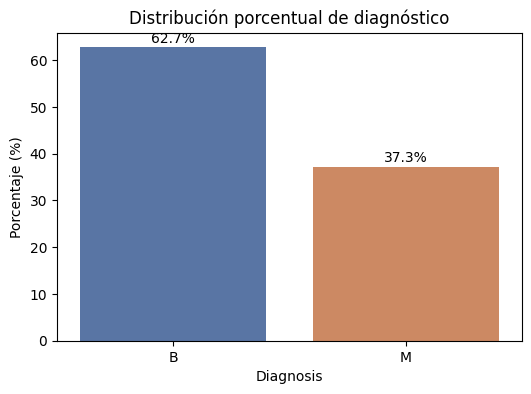

In [12]:
# Calcular porcentaje
diagnosis_pct = cancer_df['diagnosis'].value_counts(normalize=True) * 100

# Grafico
plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=diagnosis_pct.index,
    y=diagnosis_pct.values,
    hue=diagnosis_pct.index,
    palette=['#4C72B0', '#DD8452'],  # verde benigno, rojo maligno
    legend=False
)

# Agregar porcentaje encima de cada barra
for i, v in enumerate(diagnosis_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.ylabel("Porcentaje (%)")
plt.xlabel("Diagnosis")
plt.title("Distribución porcentual de diagnóstico")
plt.show()

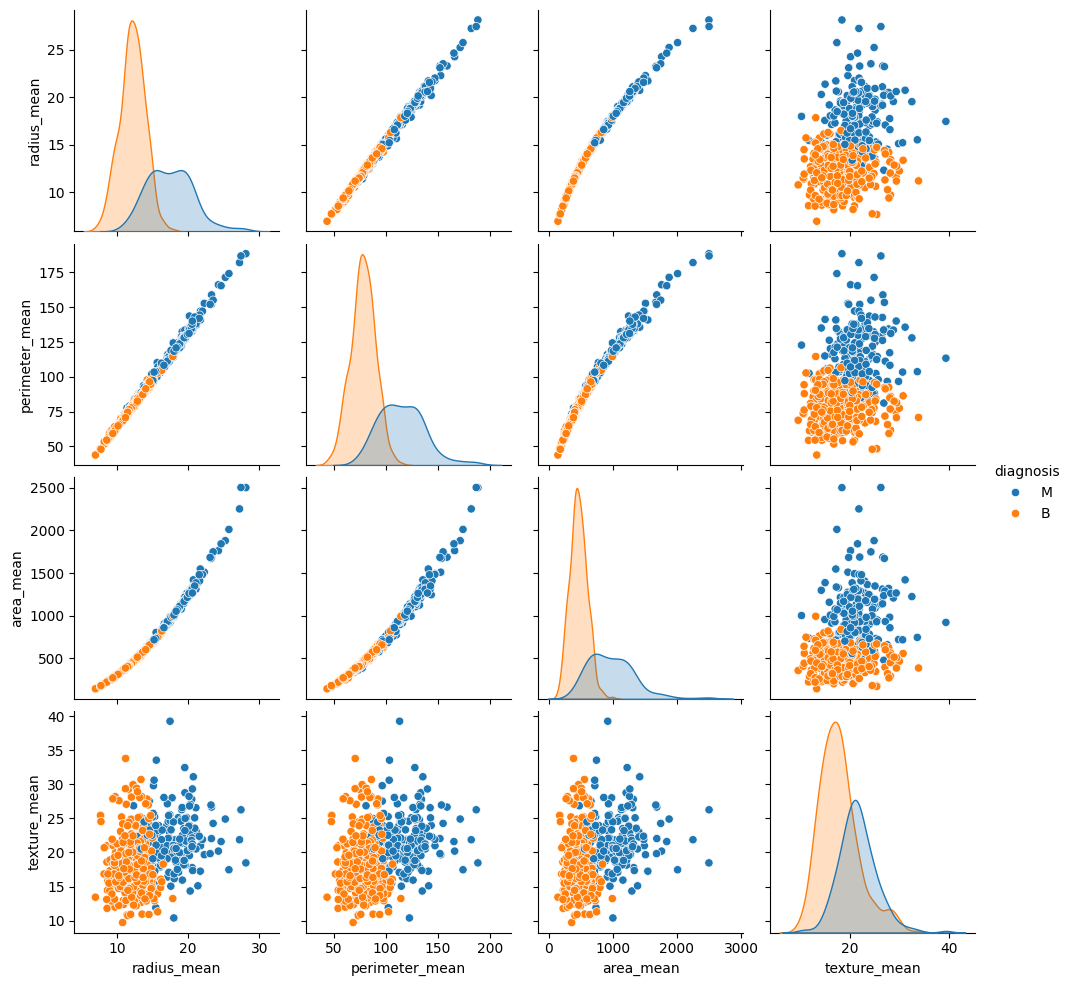

In [13]:
vars_mean = [
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'texture_mean'
]

sns.pairplot(
    cancer_df[vars_mean + ['diagnosis']],
    hue='diagnosis',
    diag_kind='kde'
)

plt.show()

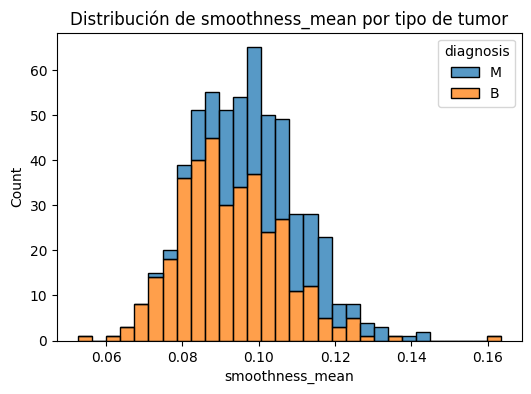

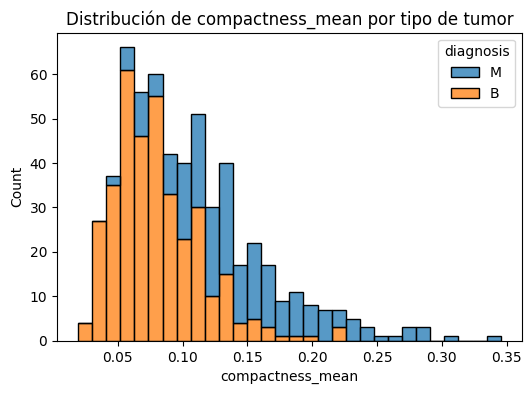

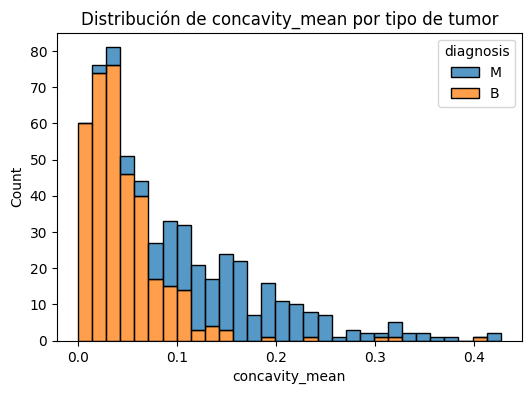

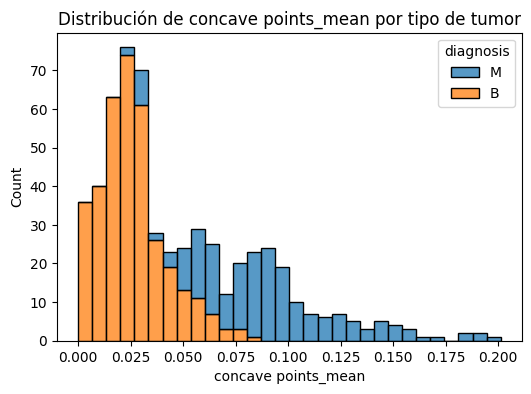

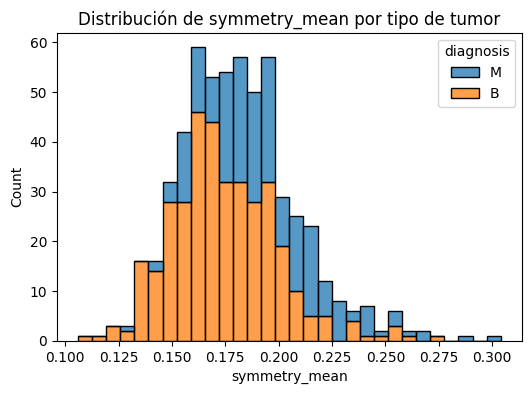

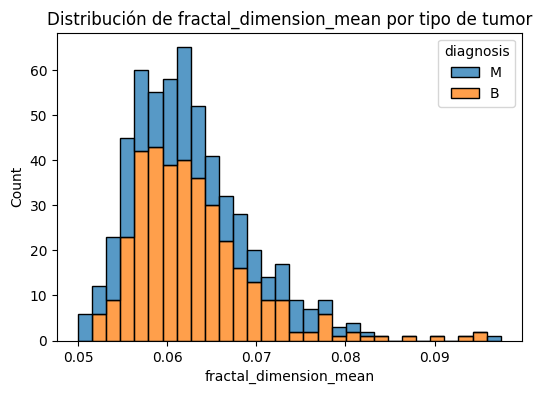

In [14]:
morph_vars = [
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean'
]

for col in morph_vars:
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        data=cancer_df,
        x=col,
        hue='diagnosis',
        bins=30,
        multiple='stack'
    )
    
    plt.title(f"Distribución de {col} por tipo de tumor")
    plt.show()

#### Conclusión

Las variables **`concavity_mean`** y **`concave points_mean`** parecen ser los mejores discriminadores entre tumores benignos y malignos, ya que muestran una separación más clara entre las distribuciones de ambas clases. En menor medida, **`compactness_mean`** también presenta cierta capacidad de diferenciación. Por otro lado, variables como **`symmetry_mean`** y **`fractal_dimension_mean`** muestran un alto grado de superposición entre las clases, por lo que su capacidad para distinguir entre tumores benignos y malignos es menor.

---

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [15]:
# crear copia
cancer_copy = cancer_df.copy()

In [16]:
# Calcular la matriz de correlación e identificar pares con correlación > 0.9
import numpy as np

corr_matrix = cancer_copy.corr(numeric_only=True)

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr.append((col1, col2, corr_matrix.iloc[i, j]))

for pair in high_corr:
    print(pair)

('perimeter_mean', 'radius_mean', np.float64(0.9978552814938109))
('area_mean', 'radius_mean', np.float64(0.9873571700566127))
('area_mean', 'perimeter_mean', np.float64(0.9865068039913907))
('concave points_mean', 'concavity_mean', np.float64(0.9213910263788588))
('perimeter_se', 'radius_se', np.float64(0.9727936770160764))
('area_se', 'radius_se', np.float64(0.951830112110991))
('area_se', 'perimeter_se', np.float64(0.9376554069544157))
('radius_worst', 'radius_mean', np.float64(0.9695389726112055))
('radius_worst', 'perimeter_mean', np.float64(0.9694763634663146))
('radius_worst', 'area_mean', np.float64(0.9627460860470841))
('texture_worst', 'texture_mean', np.float64(0.912044588840421))
('perimeter_worst', 'radius_mean', np.float64(0.9651365139559871))
('perimeter_worst', 'perimeter_mean', np.float64(0.9703868870426394))
('perimeter_worst', 'area_mean', np.float64(0.9591195743552645))
('perimeter_worst', 'radius_worst', np.float64(0.993707916102949))
('area_worst', 'radius_mean', 

In [17]:
# Eliminar variables del conjunto _worst para reducir redundancia
worst_cols = [col for col in cancer_copy.columns if "_worst" in col]

cancer_copy.drop(columns=worst_cols, inplace=True)

In [18]:
# Recalcular correlaciones altas después de eliminar columnas _worst
corr_matrix = cancer_copy.corr(numeric_only=True)

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr.append((col1, col2, corr_matrix.iloc[i, j]))

for pair in high_corr:
    print(pair)

('perimeter_mean', 'radius_mean', np.float64(0.9978552814938109))
('area_mean', 'radius_mean', np.float64(0.9873571700566127))
('area_mean', 'perimeter_mean', np.float64(0.9865068039913907))
('concave points_mean', 'concavity_mean', np.float64(0.9213910263788588))
('perimeter_se', 'radius_se', np.float64(0.9727936770160764))
('area_se', 'radius_se', np.float64(0.951830112110991))
('area_se', 'perimeter_se', np.float64(0.9376554069544157))


In [19]:
# Eliminar perimeter y area  y conservar radius
cols_to_drop = [col for col in cancer_copy.columns if 'perimeter' in col or 'area' in col]

cancer_copy.drop(columns=cols_to_drop, inplace=True)

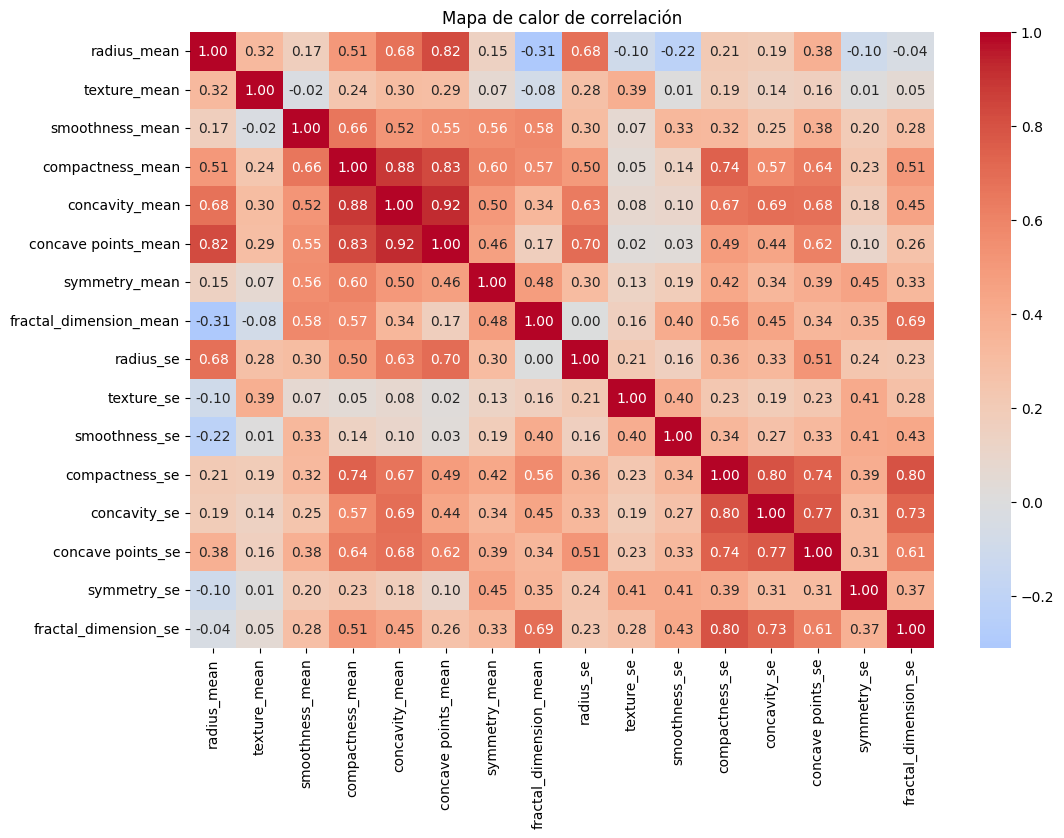

In [20]:
# Visualizar la matriz de correlación con valores en cada celda
plt.figure(figsize=(12,8))

sns.heatmap(
    cancer_copy.corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    annot=True,      # muestra el valor en cada celda
    fmt=".2f"        # mostrar solo 2 decimales
)

plt.title("Mapa de calor de correlación")
plt.show()

#### Selección de variables y análisis de correlación
Las variables `radius_mean`, `perimeter_mean` y `area_mean` presentan una correlación muy alta debido a que representan distintas formas de medir el tamaño del tumor. Se decidió conservar `radius_mean` por ser la medida más directa y eliminar `perimeter_mean` y `area_mean` para reducir la multicolinealidad.

El mapa de calor muestra que la mayoría de las correlaciones restantes son moderadas. Sin embargo, también se observa una correlación alta entre `concavity_mean` y `concave points_mean`.
___

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [21]:
# Separar X e y usando el dataframe original
X = cancer_df.drop(columns=['diagnosis'])
y = cancer_df['diagnosis']

In [22]:
# Convertir diagnosis a valores numéricos: B=0, M=1
y = y.map({'B': 0, 'M': 1})

In [23]:
# Dividir los datos en entrenamiento y prueba con random_state=1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [24]:
# Definir función para imprimir recall, precision y accuracy
def evaluate_model(y_true, y_pred):
    print('Recall   :', recall_score(y_true, y_pred))
    print('Precision:', precision_score(y_true, y_pred))
    print('Accuracy :', accuracy_score(y_true, y_pred))

In [25]:
# Revisar dimensiones de los conjuntos generados
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [26]:
# Crear transformador para eliminar columnas correlacionadas y conservar el resto
cols_to_drop = ['perimeter_mean', 'area_mean']

preprocessing = ColumnTransformer(
    transformers=[
        ('drop_corr', 'drop', cols_to_drop)
    ],
    remainder='passthrough'
)

In [27]:
# Integrar el preprocesamiento y el modelo en un pipeline
from sklearn.pipeline import Pipeline

logreg_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(max_iter=5000, random_state=1))
])

In [28]:
# Entrenar el pipeline y predecir sobre el conjunto de prueba
logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

In [29]:
# Evaluar el desempeño del modelo con la función evaluate_model
evaluate_model(y_test, y_pred_logreg)

Recall   : 0.9047619047619048
Precision: 1.0
Accuracy : 0.9649122807017544


In [30]:
# Guardar las métricas del modelo en un dataframe de resultados
results_df = pd.DataFrame([
    {
        'Model': 'Correlation_Clean',
        'Recall': recall_score(y_test, y_pred_logreg),
        'Precision': precision_score(y_test, y_pred_logreg),
        'Accuracy': accuracy_score(y_test, y_pred_logreg)
    }
])

results_df

,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.904762,1.0,0.964912


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [31]:
# Crear pipeline con StandardScaler, PCA y regresión logística
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('model', LogisticRegression(max_iter=5000, random_state=1))
])

In [32]:
# Entrenar el pipeline y generar predicciones sobre el conjunto de prueba
pca_pipeline.fit(X_train, y_train)
y_pred_pca = pca_pipeline.predict(X_test)

In [33]:
# Evaluar el desempeño del modelo con la función creada
evaluate_model(y_test, y_pred_pca)

Recall   : 0.9285714285714286
Precision: 1.0
Accuracy : 0.9736842105263158


In [34]:
# Añadir las métricas del modelo PCA al dataframe de resultados
new_result = pd.DataFrame([
    {
        'Model': 'Standard_PCA',
        'Recall': recall_score(y_test, y_pred_pca),
        'Precision': precision_score(y_test, y_pred_pca),
        'Accuracy': accuracy_score(y_test, y_pred_pca)
    }
])

results_df = pd.concat([results_df, new_result], ignore_index=True)
results_df

,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.904762,1.0,0.964912
1,Standard_PCA,0.928571,1.0,0.973684


In [35]:
# Mostrar el número de componentes principales seleccionados por PCA
n_components_used = pca_pipeline.named_steps['pca'].n_components_
print('Número de componentes principales:', n_components_used)

Número de componentes principales: 7


#### Conclusión

Se construyó un pipeline que integra escalado estándar, análisis de componentes principales (PCA) y regresión logística para reducir la multicolinealidad mediante transformación de variables. El modelo fue entrenado con el conjunto de entrenamiento y evaluado con el conjunto de prueba.

El modelo obtuvo una exactitud de aproximadamente 97.4%, un recall de 0.9286 y una precisión de 1.0, mostrando un desempeño ligeramente superior al modelo que únicamente eliminaba variables altamente correlacionadas.

El PCA redujo las 30 variables originales a 7 componentes principales, los cuales explican al menos el 90% de la varianza del conjunto de datos.
___

7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [36]:
# Crear pipeline con eliminación de columnas correlacionadas, transformación Yeo-Johnson y regresión logística
yeo_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('yeo', PowerTransformer(method='yeo-johnson')),
    ('model', LogisticRegression(max_iter=5000, random_state=1))
])

In [37]:
# Entrenar el pipeline y predecir sobre el conjunto de prueba
yeo_pipeline.fit(X_train, y_train)
y_pred_yeo = yeo_pipeline.predict(X_test)

In [38]:
# Evaluar el desempeño del modelo con la función creada
evaluate_model(y_test, y_pred_yeo)

Recall   : 0.9285714285714286
Precision: 1.0
Accuracy : 0.9736842105263158


In [39]:
# Añadir las métricas del modelo con Yeo-Johnson al dataframe de resultados
new_result = pd.DataFrame([
    {
        'Model': 'Correlation_Yeo',
        'Recall': recall_score(y_test, y_pred_yeo),
        'Precision': precision_score(y_test, y_pred_yeo),
        'Accuracy': accuracy_score(y_test, y_pred_yeo)
    }
])

results_df = pd.concat([results_df, new_result], ignore_index=True)
results_df

,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.904762,1.0,0.964912
1,Standard_PCA,0.928571,1.0,0.973684
2,Correlation_Yeo,0.928571,1.0,0.973684


#### Conclusión

Se construyó un pipeline que integra la eliminación de variables altamente correlacionadas, una transformación Yeo-Johnson y regresión logística. Esta transformación permite reducir el sesgo en las variables sin requerir que los datos sean estrictamente positivos.

El modelo obtuvo un recall de 0.9286, una precisión de 1.0 y una exactitud de aproximadamente 97.37%. Sin embargo, los resultados fueron idénticos a los obtenidos con el modelo basado en PCA, lo que sugiere que la transformación Yeo-Johnson no produjo una mejora adicional en el desempeño del modelo para este conjunto de datos.

En general, los modelos muestran un desempeño alto en la clasificación de tumores benignos y malignos.
___

8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.

In [40]:
# Obtener los nombres de las variables después del preprocessing
feature_names = yeo_pipeline.named_steps['preprocessing'].get_feature_names_out()

print("Numero de predictores:", len(feature_names))
print(feature_names)

Numero de predictores: 28
['remainder__radius_mean' 'remainder__texture_mean'
 'remainder__smoothness_mean' 'remainder__compactness_mean'
 'remainder__concavity_mean' 'remainder__concave points_mean'
 'remainder__symmetry_mean' 'remainder__fractal_dimension_mean'
 'remainder__radius_se' 'remainder__texture_se' 'remainder__perimeter_se'
 'remainder__area_se' 'remainder__smoothness_se'
 'remainder__compactness_se' 'remainder__concavity_se'
 'remainder__concave points_se' 'remainder__symmetry_se'
 'remainder__fractal_dimension_se' 'remainder__radius_worst'
 'remainder__texture_worst' 'remainder__perimeter_worst'
 'remainder__area_worst' 'remainder__smoothness_worst'
 'remainder__compactness_worst' 'remainder__concavity_worst'
 'remainder__concave points_worst' 'remainder__symmetry_worst'
 'remainder__fractal_dimension_worst']


In [41]:
# Obtener coeficientes del modelo de regresión logística
coefficients = yeo_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df.head()

,Feature,Coefficient
0,remainder__radius_mean,0.466181
1,remainder__texture_mean,0.783984
2,remainder__smoothness_mean,0.260425
3,remainder__compactness_mean,-0.326216
4,remainder__concavity_mean,0.976020


In [42]:
# Seleccionar las 10 variables mas influyentes
top10 = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(10)

top10

,Feature,Coefficient
13,remainder__compactness_se,-1.116332
19,remainder__texture_worst,1.096322
5,remainder__concave points_mean,1.078565
11,remainder__area_se,1.038642
4,remainder__concavity_mean,0.976020
21,remainder__area_worst,0.913236
24,remainder__concavity_worst,0.898981
18,remainder__radius_worst,0.868129
20,remainder__perimeter_worst,0.785002
1,remainder__texture_mean,0.783984


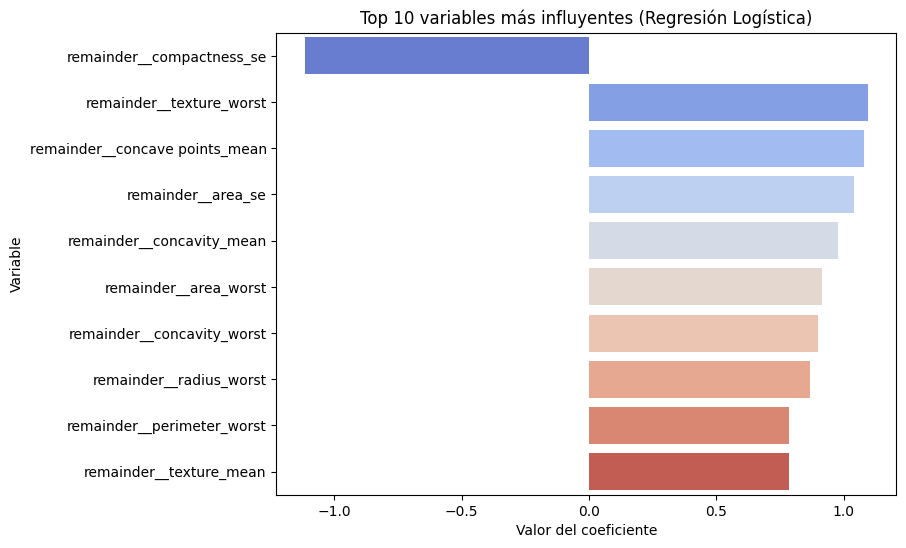

In [43]:
# Graficar coeficientes en un barplot horizontal sin warning
plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette='coolwarm',
    legend=False
)

plt.title('Top 10 variables más influyentes (Regresión Logística)')
plt.xlabel('Valor del coeficiente')
plt.ylabel('Variable')

plt.show()

#### Conclusión

El modelo de regresión logística utiliza 28 variables predictoras después del proceso de preprocesamiento. Al analizar la magnitud de los coeficientes se identificaron las 10 variables más influyentes en la predicción del diagnóstico.

Entre las variables con mayor impacto se encuentran aquellas relacionadas con la concavidad del tumor, el número de puntos cóncavos y características de tamaño como área, radio y perímetro. Estas variables presentan coeficientes positivos elevados, lo que indica que aumentan la probabilidad de clasificar un tumor como maligno.

El análisis de los coeficientes permite interpretar qué características del tumor influyen más en la decisión del modelo y proporciona una visión más explicable del proceso de clasificación.
___

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

In [44]:
# Mostrar el dataframe con los resultados de los modelos
results_df

,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.904762,1.0,0.964912
1,Standard_PCA,0.928571,1.0,0.973684
2,Correlation_Yeo,0.928571,1.0,0.973684


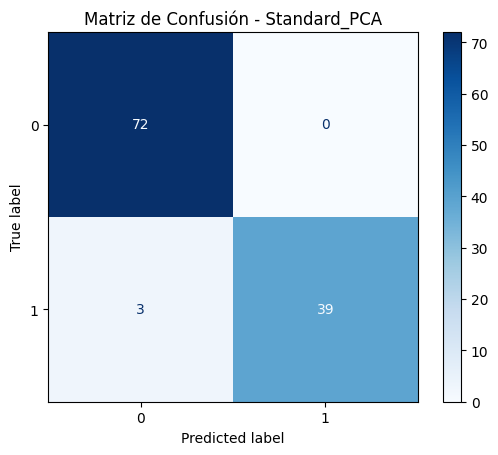

In [45]:
# Dibujar la matriz de confusión del mejor modelo
cm = confusion_matrix(y_test, y_pred_pca)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Standard_PCA')
plt.show()

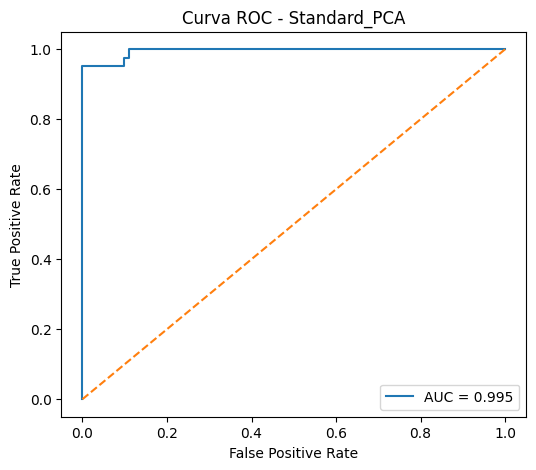

In [46]:
# Calcular probabilidades para la curva ROC
y_prob = pca_pipeline.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Standard_PCA')
plt.legend()

plt.show()

#### Resultados del modelo

El dataframe de resultados muestra el desempeño de los tres modelos evaluados:

- **Correlation_Clean**
- **Standard_PCA**
- **Correlation_Yeo**

Los modelos **Standard_PCA** y **Correlation_Yeo** obtuvieron el mejor desempeño con una exactitud aproximada de **97.37%**.

#### Matriz de confusión

La matriz de confusión del modelo **Standard_PCA** presenta los siguientes valores:

- **72 Verdaderos Negativos (TN)**: tumores benignos correctamente clasificados como benignos.
- **0 Falsos Positivos (FP)**: tumores benignos clasificados incorrectamente como malignos.
- **3 Falsos Negativos (FN)**: tumores malignos clasificados incorrectamente como benignos.
- **39 Verdaderos Positivos (TP)**: tumores malignos correctamente identificados.

Esto indica que el modelo tiene un excelente desempeño, ya que clasifica correctamente la mayoría de los casos. Sin embargo, existen **3 falsos negativos**, lo cual es importante en contextos médicos porque implica no detectar algunos tumores malignos.

#### Curva ROC

La curva ROC del modelo muestra un **AUC = 0.995**, lo que indica una capacidad de discriminación **casi perfecta** entre tumores benignos y malignos.

La curva se encuentra muy cercana a la esquina superior izquierda del gráfico, lo que significa que el modelo logra una **alta tasa de verdaderos positivos con una tasa muy baja de falsos positivos**. Esto confirma que el modelo es altamente efectivo para distinguir entre ambas clases.
___

10. Grafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

In [47]:
# Obtener la probabilidad de pertenecer a la clase Maligno (1)
y_prob = pca_pipeline.predict_proba(X_test)[:, 1]

In [48]:
# Crear dataframe con probabilidades y clase real para facilitar la visualización
prob_df = pd.DataFrame({
    'Prob_Maligno': y_prob,
    'Diagnosis': y_test.map({0: 'B', 1: 'M'})
})

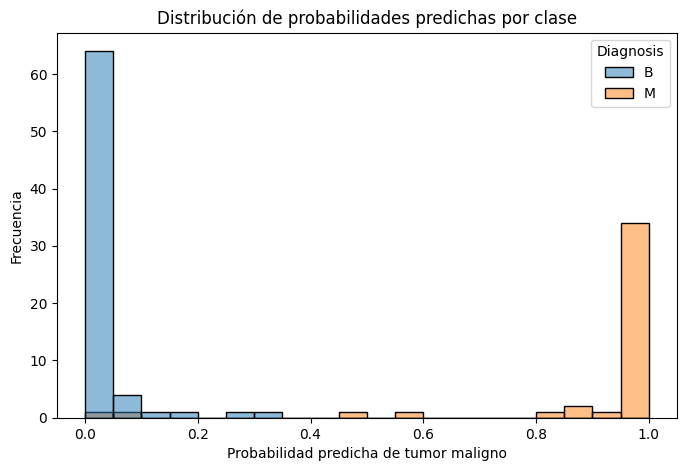

In [49]:
# Graficar la distribución de probabilidades predichas para benignos y malignos
plt.figure(figsize=(8,5))

sns.histplot(
    data=prob_df,
    x='Prob_Maligno',
    hue='Diagnosis',
    bins=20,
    multiple='layer',
    alpha=0.5
)

plt.title('Distribución de probabilidades predichas por clase')
plt.xlabel('Probabilidad predicha de tumor maligno')
plt.ylabel('Frecuencia')
plt.show()

#### Interpretación de la distribución de probabilidades

La gráfica muestra la distribución de las probabilidades predichas por el modelo para cada clase. Se observa que la mayoría de los tumores benignos (B) tienen probabilidades cercanas a 0, mientras que los tumores malignos (M) presentan probabilidades cercanas a 1. Existe muy poco solapamiento entre ambas distribuciones, lo que indica que el modelo tiene una buena capacidad para distinguir entre las dos clases.

#### Umbral por defecto

El umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias es **0.5**. Si la probabilidad predicha para la clase positiva (maligno) es mayor o igual a 0.5, el modelo clasifica el caso como maligno; en caso contrario, lo clasifica como benigno.

#### Métrica más importante en diagnóstico médico

En un modelo de diagnóstico médico, la métrica más importante suele ser el **recall** (sensibilidad), ya que mide la capacidad del modelo para detectar correctamente los casos positivos. En este caso, es crucial identificar la mayor cantidad posible de tumores malignos para reducir el número de falsos negativos.

#### Ajuste del threshold

En este tipo de problemas generalmente conviene **disminuir el threshold**. Al reducir el umbral, el modelo clasificará más casos como malignos, lo que aumenta la probabilidad de detectar tumores malignos y reduce los falsos negativos. Aunque esto puede incrementar los falsos positivos, en medicina suele ser preferible realizar estudios adicionales a un paciente sano que dejar sin detectar un tumor maligno.